In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Importamos tu pipeline Y las funciones del EDA
from cargar_datos import cargar_base_datos
from ft_engineering import ft_engineering, aplicar_filtros_eda, crear_variables_nuevas

print("--- 1. PREPARACIÓN DE DATOS (LIMPIEZA TOTAL) ---")
df = cargar_base_datos()

# --- EL CAMBIO NECESARIO: Filtros y variables del EDA ---
df = aplicar_filtros_eda(df)
df = crear_variables_nuevas(df)
# --------------------------------------------------------

# Lista negra definitiva: ¡Se van ambos puntajes!
columnas_a_eliminar = [
    'fecha_prestamo', 'huella_consulta', 'tendencia_ingresos', 
    'promedio_ingresos_datacredito', 'saldo_mora', 'saldo_mora_codeudor',
    'saldo_total', 'saldo_principal', 'puntaje', 'puntaje_datacredito'
]
df = df.drop(columns=columnas_a_eliminar, errors='ignore').dropna(subset=['Pago_atiempo'])

X = df.drop('Pago_atiempo', axis=1)
# Transformamos: Si Pago_atiempo es 0 (No pagó), lo convertimos en 1 (¡Alerta Moroso!). Si pagó, es 0.
y = (df['Pago_atiempo'] == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Engineering
preprocessor = ft_engineering(X_train)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"Datos listos. Dimensiones de entrenamiento: {X_train_processed.shape}")

--- 1. PREPARACIÓN DE DATOS (LIMPIEZA TOTAL) ---
Iniciando proceso de carga...
Buscando el archivo en la ruta exacta:
c:\Users\ADMIN\OneDrive\Desktop\Data science\mlops_pipeline\mlops_pipeline\src\..\Base_de_datos.xlsx

¡Carga exitosa!
El dataset tiene 10763 filas (clientes) y 23 columnas (variables).

Columnas encontradas:
['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'tendencia_ingresos', 'Pago_atiempo']
Datos listos. Dimensiones de entrenamiento: (8471, 15)


--- 2. DEFINICIÓN DE FUNCIONES DE EVALUACIÓN (RÚBRICA) ---
--- 3. ENTRENAMIENTO DE MODELOS ---
Ejecutando build_model para: Regresión Logística (Base)...
Ejecutando build_model para: Árbol de Decisión...
Ejecutando build_model para: Random Forest...
Ejecutando build_model para: LightGBM...


c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ejecutando build_model para: XGBoost...

--- TABLA COMPARATIVA DE RENDIMIENTO ---


,Model,Accuracy,Precision,Recall,F1-Score,Execution_Time (s)
0,Regresión Logística (Base),0.6001,0.0569,0.48,0.1018,0.0774
3,LightGBM,0.9004,0.1224,0.18,0.1457,2.2383
4,XGBoost,0.9268,0.1127,0.08,0.0936,0.1847
1,Árbol de Decisión,0.9027,0.0583,0.07,0.0636,0.0365
2,Random Forest,0.9528,0.0000,0.00,0.0000,0.5616


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10868\786275494.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resumen, x='Model', y='Execution_Time (s)', palette='viridis')


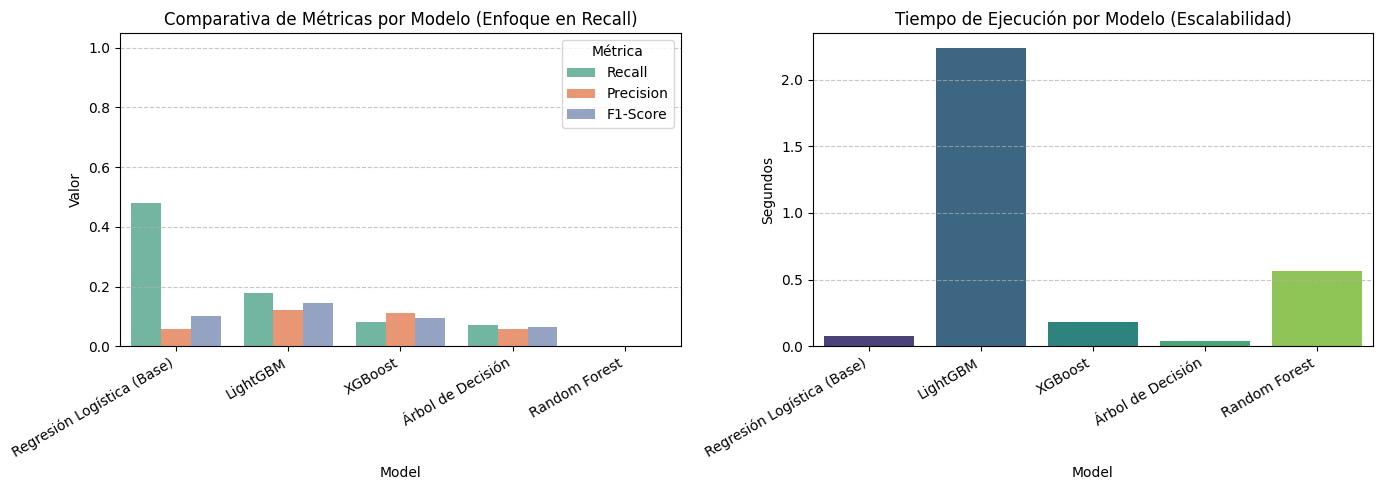

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("--- 2. DEFINICIÓN DE FUNCIONES DE EVALUACIÓN (RÚBRICA) ---")

def summarize_classification(y_true, y_pred, model_name):
    """
    Calcula y estructura las métricas clave del modelo.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    }

def build_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Entrena el modelo, genera predicciones y mide el tiempo de ejecución.
    """
    start_time = time.time()
    
    # Entrenamiento
    model.fit(X_train, y_train)
    
    # Predicción
    y_pred = model.predict(X_test)
    
    execution_time = time.time() - start_time
    
    # Resumen de métricas
    metrics = summarize_classification(y_test, y_pred, model_name)
    metrics['Execution_Time (s)'] = round(execution_time, 4)
    
    return metrics, model

print("--- 3. ENTRENAMIENTO DE MODELOS ---")

# Calculamos ratio para XGBoost
ratio_desbalanceo = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Definición del arsenal de modelos con tratamiento de desbalanceo
dict_modelos = {
    "Regresión Logística (Base)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=ratio_desbalanceo, random_state=42, eval_metric='logloss')
}

resultados_lista = []
modelos_entrenados = {}

# Bucle principal usando build_model
for nombre, instancia_modelo in dict_modelos.items():
    print(f"Ejecutando build_model para: {nombre}...")
    metricas, modelo_fit = build_model(
        instancia_modelo, 
        X_train_processed, 
        y_train, 
        X_test_processed, 
        y_test, 
        nombre
    )
    resultados_lista.append(metricas)
    modelos_entrenados[nombre] = modelo_fit

# --- 4. TABLA RESUMEN FINAL ---
df_resumen = pd.DataFrame(resultados_lista).sort_values(by='Recall', ascending=False)
print("\n--- TABLA COMPARATIVA DE RENDIMIENTO ---")
display(df_resumen)

# --- 5. GRÁFICOS COMPARATIVOS ---
plt.figure(figsize=(14, 5))

# Gráfico 1: Métricas de Rendimiento (Recall vs Precision vs F1)
plt.subplot(1, 2, 1)
df_melted = df_resumen.melt(id_vars=['Model'], value_vars=['Recall', 'Precision', 'F1-Score'], 
                            var_name='Métrica', value_name='Valor')
sns.barplot(data=df_melted, x='Model', y='Valor', hue='Métrica', palette='Set2')
plt.title('Comparativa de Métricas por Modelo (Enfoque en Recall)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 2: Tiempo de Ejecución (Escalabilidad)
plt.subplot(1, 2, 2)
sns.barplot(data=df_resumen, x='Model', y='Execution_Time (s)', palette='viridis')
plt.title('Tiempo de Ejecución por Modelo (Escalabilidad)')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Segundos')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [3]:
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print("--- PARTE 2: VALIDACIÓN CRUZADA Y ENSAMBLE AVANZADO (STACKING) ---")

# Calculamos el ratio para XGBoost (Mayoría / Minoría)
ratio_desbalanceo = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Definimos los modelos base
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
lgbm = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
# allow_writing_files=False previene el error de colisión de disco que tuvimos antes
cat = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0, allow_writing_files=False)
xgb = XGBClassifier(scale_pos_weight=ratio_desbalanceo, random_state=42, eval_metric='logloss')
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Construimos el StackingClassifier
stacking_clf = StackingClassifier(
    estimators=[
        ('RandomForest', rf),
        ('LightGBM', lgbm),
        ('CatBoost', cat)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, 
    n_jobs=-1 
)

# Diccionario de competidores para CV
modelos_cv = {
    "Regresión Logística": log_reg,
    "Random Forest": rf,
    "LightGBM": lgbm,
    "XGBoost": xgb,
    "CatBoost": cat,
    "🏆 Stacking (RF+LGBM+CAT)": stacking_clf
}

# Garantizamos proporción Sí/No en los 5 cortes
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas_a_medir = ['accuracy', 'precision', 'recall', 'f1']
resultados_cv = []

for nombre, modelo in modelos_cv.items():
    print(f"Validación Cruzada (5-Folds) en proceso para: {nombre}...")
    start_time = time.time()
    
    # Entrenamiento y evaluación automática
    scores = cross_validate(
        modelo, 
        X_train_processed, 
        y_train, 
        cv=skf, 
        scoring=metricas_a_medir, 
        n_jobs=-1 
    )
    
    tiempo_total = time.time() - start_time
    
    resultados_cv.append({
        'Modelo': nombre,
        'Mean_Accuracy': round(np.mean(scores['test_accuracy']), 4),
        'Mean_Precision': round(np.mean(scores['test_precision']), 4),
        'Mean_Recall': round(np.mean(scores['test_recall']), 4),
        'Mean_F1': round(np.mean(scores['test_f1']), 4),
        'Tiempo_Total (s)': round(tiempo_total, 4)
    })

print("\n--- RESULTADOS DE VALIDACIÓN CRUZADA (5-FOLDS) ---")
df_cv = pd.DataFrame(resultados_cv).sort_values(by='Mean_Recall', ascending=False)
display(df_cv)

--- PARTE 2: VALIDACIÓN CRUZADA Y ENSAMBLE AVANZADO (STACKING) ---
Validación Cruzada (5-Folds) en proceso para: Regresión Logística...
Validación Cruzada (5-Folds) en proceso para: Random Forest...
Validación Cruzada (5-Folds) en proceso para: LightGBM...
Validación Cruzada (5-Folds) en proceso para: XGBoost...
Validación Cruzada (5-Folds) en proceso para: CatBoost...
Validación Cruzada (5-Folds) en proceso para: 🏆 Stacking (RF+LGBM+CAT)...

--- RESULTADOS DE VALIDACIÓN CRUZADA (5-FOLDS) ---


,Modelo,Mean_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Tiempo_Total (s)
0,Regresión Logística,0.6186,0.0644,0.5260,0.1147,1.8540
2,LightGBM,0.9086,0.1253,0.1478,0.1341,3.3565
4,CatBoost,0.9125,0.1226,0.1378,0.1294,3.7310
3,XGBoost,0.9341,0.1405,0.0801,0.1015,1.4496
1,Random Forest,0.9527,0.0000,0.0000,0.0000,1.7382
5,🏆 Stacking (RF+LGBM+CAT),0.9529,0.0000,0.0000,0.0000,15.4866


--- 4. EVALUACIÓN VISUAL AVANZADA (ROC-AUC Y PRECISION-RECALL) ---


c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


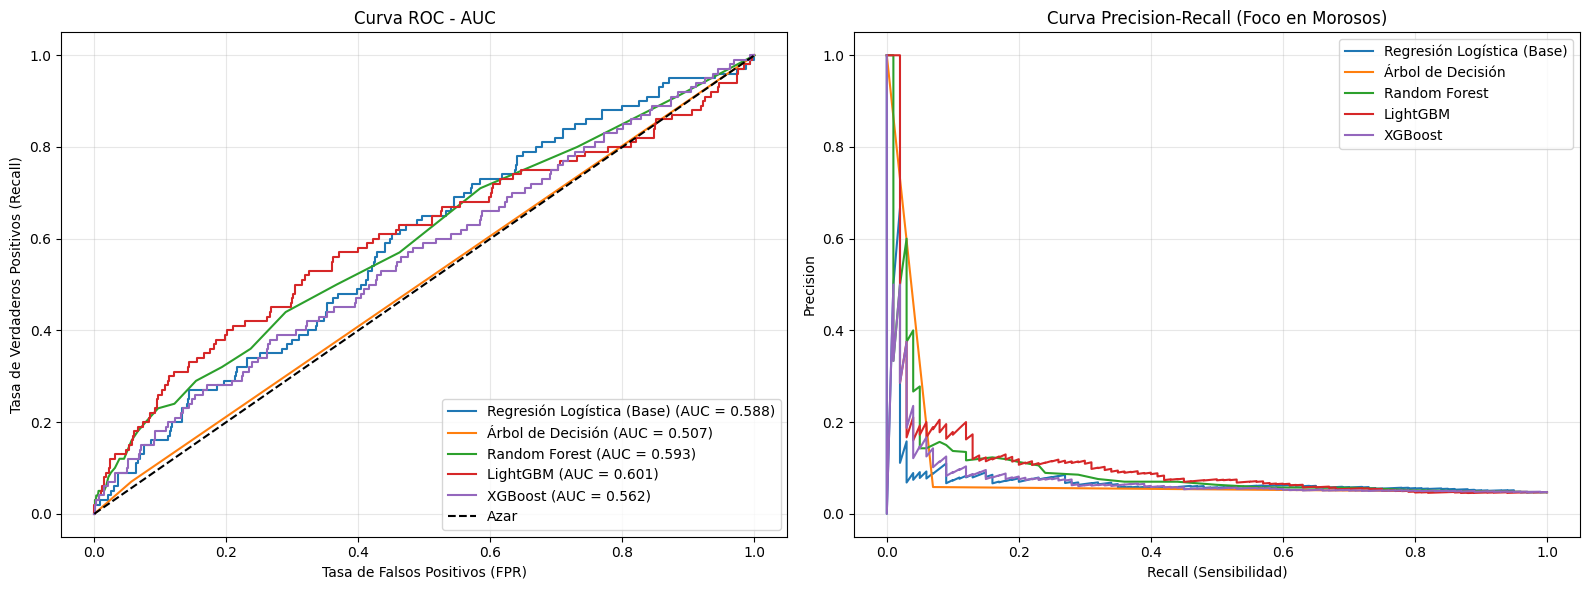


--- MATRIZ DE CONFUSIÓN: EL CAMPEÓN (LightGBM) ---


c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


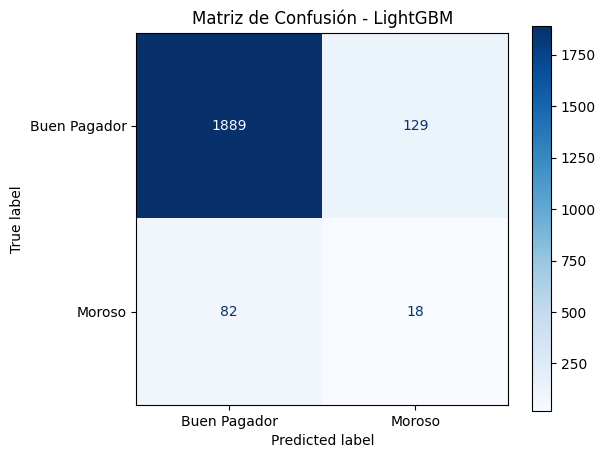

In [7]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- 4. EVALUACIÓN VISUAL AVANZADA (ROC-AUC Y PRECISION-RECALL) ---")

plt.figure(figsize=(16, 6))

# --- Gráfica 1: Curva ROC (Receiver Operating Characteristic) ---
plt.subplot(1, 2, 1)
for nombre, modelo in modelos_entrenados.items():
    # Extraemos la probabilidad de que el cliente sea Moroso (Clase 1)
    y_probs = modelo.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc:.3f})')

# Línea base de un modelo aleatorio (azar)
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - AUC')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# --- Gráfica 2: Curva Precision-Recall (Ideal para Desbalanceo) ---
plt.subplot(1, 2, 2)
for nombre, modelo in modelos_entrenados.items():
    y_probs = modelo.predict_proba(X_test_processed)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    plt.plot(recall, precision, label=nombre)

plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall (Foco en Morosos)')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Gráfica 3: Matriz de Confusión del Campeón (LightGBM) ---
print("\n--- MATRIZ DE CONFUSIÓN: EL CAMPEÓN (LightGBM) ---")
# Extraemos nuestro mejor modelo balanceado
modelo_seleccionado = modelos_entrenados["LightGBM"]

# Dibujamos cómo se equivocó exactamente
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    modelo_seleccionado, 
    X_test_processed, 
    y_test,
    display_labels=['Buen Pagador', 'Moroso'],
    cmap='Blues', 
    normalize=None,
    ax=ax
)
plt.title("Matriz de Confusión - LightGBM")
plt.grid(False) # Apagamos la grilla para que se vea limpio
plt.show()